In [1]:
import pandas as pd

df_AAPL = pd.read_csv(r'D:\KAIM-9\Week-1\news-sentiment-analysis\data\Data\AAPL.csv')
df_AMZN = pd.read_csv(r'D:\KAIM-9\Week-1\news-sentiment-analysis\data\Data\AMZN.csv')
df_GOOG = pd.read_csv(r'D:\KAIM-9\Week-1\news-sentiment-analysis\data\Data\GOOG.csv')
df_META = pd.read_csv(r'D:\KAIM-9\Week-1\news-sentiment-analysis\data\Data\META.csv')
df_NVDA = pd.read_csv(r'D:\KAIM-9\Week-1\news-sentiment-analysis\data\Data\NVDA.csv')

In [2]:
print("--- Original Info for df_AAPL ---")
df_AAPL.info()

# Reset index if Date is already the index
if df_AAPL.index.name == 'Date':
    df_AAPL.reset_index(inplace=True)

# Convert 'Date' to datetime and set as index
df_AAPL['Date'] = pd.to_datetime(df_AAPL['Date'])
df_AAPL.set_index('Date', inplace=True)

# Ensure all relevant columns are numeric
# The names match the requirement: Open, High, Low, Close, Volume
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
for col in numeric_cols:
    if col in df_AAPL.columns:
        df_AAPL[col] = pd.to_numeric(df_AAPL[col], errors='coerce')

# Check for missing values after conversion and handle them (e.g., forward fill, then drop any remaining)
df_AAPL.ffill(inplace=True)
df_AAPL.dropna(inplace=True)

print("\n--- Processed Info for df_AAPL ---")
df_AAPL.info()
print("\n--- First 5 rows of Processed df_AAPL ---")
display(df_AAPL.head())

--- Original Info for df_AAPL ---
<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   str    
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 177.0 KB

--- Processed Info for df_AAPL ---
<class 'pandas.DataFrame'>
DatetimeIndex: 3774 entries, 2009-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3774 non-null   float64
 1   High    3774 non-null   float64
 2   Low     3774 non-null   float64
 3   Open    3774 non-null   float64
 4   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 176.9 KB

--- First 5 rows of Processed df_AAPL ---


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Calculating Technical Indicators for df_AAPL...
Technical Indicators calculated. Displaying first 5 rows with new indicators:


,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,EMA_50,RSI,MACD,MACD_Signal,MACD_Hist,BB_Upper,BB_Middle,BB_Lower
Date,,,,,,,,,,,,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


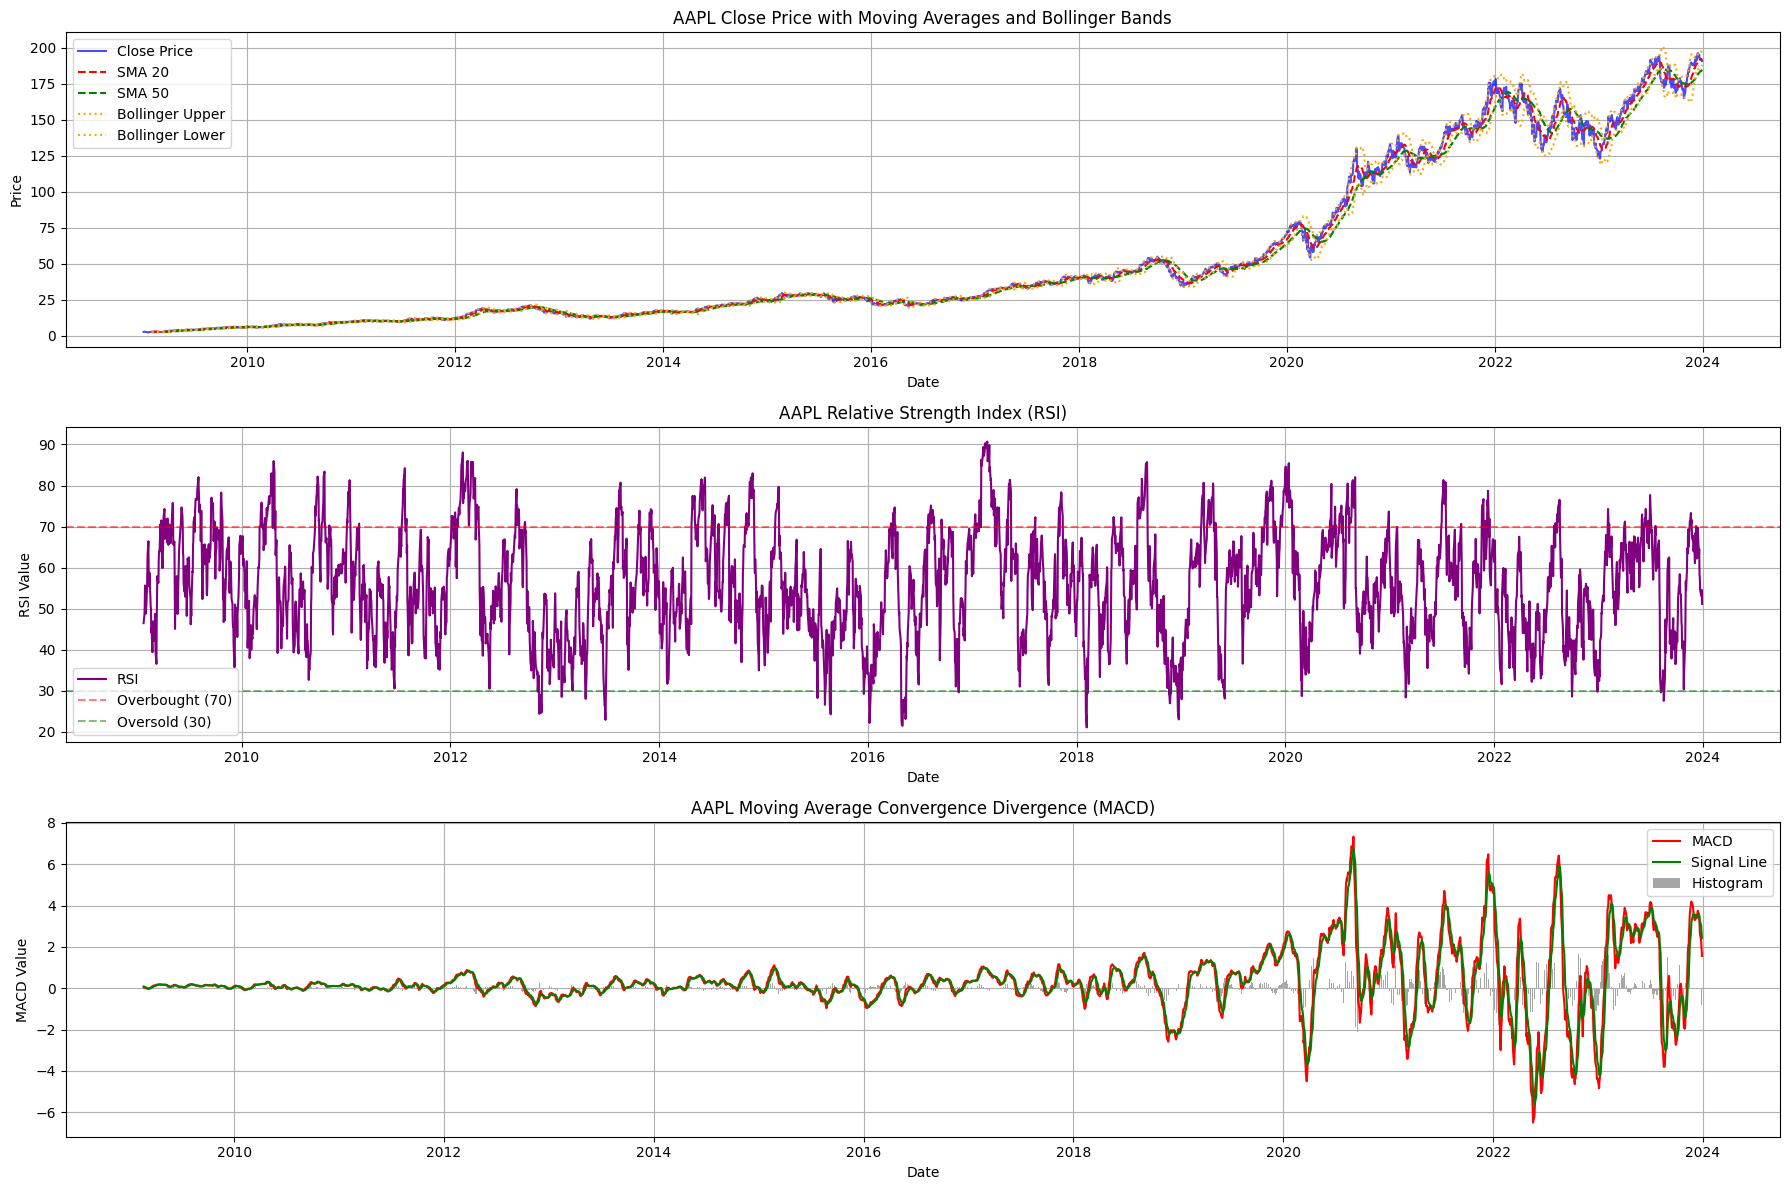

In [3]:

!pip install ta-lib
import talib as ta
import matplotlib.pyplot as plt

print("Calculating Technical Indicators for df_AAPL...")

# 1. Simple Moving Average (SMA)
df_AAPL['SMA_20'] = ta.SMA(df_AAPL['Close'], timeperiod=20)
df_AAPL['SMA_50'] = ta.SMA(df_AAPL['Close'], timeperiod=50)

# 2. Exponential Moving Average (EMA)
df_AAPL['EMA_20'] = ta.EMA(df_AAPL['Close'], timeperiod=20)
df_AAPL['EMA_50'] = ta.EMA(df_AAPL['Close'], timeperiod=50)

# 3. Relative Strength Index (RSI)
df_AAPL['RSI'] = ta.RSI(df_AAPL['Close'], timeperiod=14)

# 4. Moving Average Convergence Divergence (MACD)
# MACD, MACD_Signal, MACD_Hist
macd, macdsignal, macdhist = ta.MACD(df_AAPL['Close'], fastperiod=12, slowperiod=26, signalperiod=9)
df_AAPL['MACD'] = macd
df_AAPL['MACD_Signal'] = macdsignal
df_AAPL['MACD_Hist'] = macdhist

# 5. Bollinger Bands
df_AAPL['BB_Upper'], df_AAPL['BB_Middle'], df_AAPL['BB_Lower'] = ta.BBANDS(df_AAPL['Close'], timeperiod=20)

print("Technical Indicators calculated. Displaying first 5 rows with new indicators:")
display(df_AAPL.head())

# Visualize the indicators
plt.figure(figsize=(18, 12))

# Plot Close Price and Moving Averages
plt.subplot(3, 1, 1)
plt.plot(df_AAPL['Close'], label='Close Price', color='blue', alpha=0.7)
plt.plot(df_AAPL['SMA_20'], label='SMA 20', color='red', linestyle='--')
plt.plot(df_AAPL['SMA_50'], label='SMA 50', color='green', linestyle='--')
plt.plot(df_AAPL['BB_Upper'], label='Bollinger Upper', color='orange', linestyle=':')
plt.plot(df_AAPL['BB_Lower'], label='Bollinger Lower', color='orange', linestyle=':')
plt.title('AAPL Close Price with Moving Averages and Bollinger Bands')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

# Plot RSI
plt.subplot(3, 1, 2)
plt.plot(df_AAPL['RSI'], label='RSI', color='purple')
plt.axhline(70, linestyle='--', alpha=0.5, color='red', label='Overbought (70)')
plt.axhline(30, linestyle='--', alpha=0.5, color='green', label='Oversold (30)')
plt.title('AAPL Relative Strength Index (RSI)')
plt.xlabel('Date')
plt.ylabel('RSI Value')
plt.legend()
plt.grid(True)

# Plot MACD
plt.subplot(3, 1, 3)
plt.plot(df_AAPL['MACD'], label='MACD', color='red')
plt.plot(df_AAPL['MACD_Signal'], label='Signal Line', color='green')
plt.bar(df_AAPL.index, df_AAPL['MACD_Hist'], label='Histogram', color='grey', alpha=0.7)
plt.title('AAPL Moving Average Convergence Divergence (MACD)')
plt.xlabel('Date')
plt.ylabel('MACD Value')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

print("Calculating additional financial metrics for df_AAPL...")

# Calculate Volatility
# Calculate daily returns
df_AAPL['Daily_Return'] = df_AAPL['Close'].pct_change()

# Remove NaN values that result from pct_change before further processing
df_AAPL_pn = df_AAPL.dropna(subset=['Daily_Return']).copy()

# Annualized Volatility = Standard Deviation of Daily Returns * sqrt(252) (trading days in a year)
df_AAPL['Annual_Volatility'] = df_AAPL['Daily_Return'].rolling(window=20).std() * np.sqrt(252)

# Cumulative Return
df_AAPL['Cumulative_Return'] = (1 + df_AAPL['Daily_Return']).cumprod()

print("Additional financial metrics calculated. Displaying first 5 rows with new metrics:")
display(df_AAPL.head())

# Visualize Annual Volatility and Cumulative Return
plt.figure(figsize=(18, 10))

plt.subplot(2, 1, 1)
plt.plot(df_AAPL['Annual_Volatility'], label='Annual Volatility', color='purple')
plt.title('AAPL Annual Volatility (20-day Rolling)')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(df_AAPL['Cumulative_Return'], label='Cumulative Return', color='orange')
plt.title('AAPL Cumulative Return')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

TypeError: deprecate_kwarg() missing 1 required positional argument: 'new_arg_name'